In [1]:
# 20241203 添加msll的计算
import torch
import torch.nn as nn
from networks import FullyConnectedNN, NoisyFullyConnectedNN, FixNoiseFullyConnectedNN, DropoutFullyConnectedNN
import os
import pandas as pd
import numpy as np
from utils import *
import shutil
import re
from config import configs
from matplotlib import pyplot as plt

{'datasets': ['protein-tertiary-structure'], 'models': ['noisyFCN'], 'optimizer_name': 'Adam', 'hyperparam_eval_interval': 10, 'patience': 3, 'global_max_epochs': 2000, 'dropout_probs': [0.2, 0.1, 0.05, 0.01, 0.005, 0.001], 'fix_noiselevels': [0.001, 0.005, 0.01, 0.05, 0.1], 'init_noiselevels': [0.001, 0.005, 0.01, 0.05, 0.1], 'batch_sizes': [32], 'batch_sizes_specific': {'energy': [32]}, 'weight_decays': [0.01], 'dropout_batch_size': 32, 'n_hidden': 2, 'nonlinearity': 'relu', 'learning_rates': [0.002], 'mc_samples': 500, 'num_units': 50, 'num_units_specific': {'protein-tertiary-structure': 100}, 'normalize_X': True, 'normalize_y': True, 'n_folds': 5, 'inverted_cv_fraction': 5}


In [2]:
best_settings = pd.read_csv('settings_loss.csv', index_col=0)

In [3]:
def normalize(X_train, y_train, normalize_X=True, normalize_y=False):
    X_mean = X_train.mean(axis=0)
    X_std = X_train.std(axis=0)
    y_mean = y_train.mean(axis=0)
    y_std = y_train.std(axis=0)

    # Set std dev to 1 for constant features
    X_std[np.all(X_train == X_train[0, :], axis=0)] = 1.0

    X_train = (X_train - X_mean) / X_std if normalize_X else X_train
    y_train = (y_train - y_mean) / y_std if normalize_y else y_train
    return X_train, y_train

In [4]:
batch_size = 32
optimizer_name = "Adam"
normalize_X = configs['normalize_X']
normalize_y = configs['normalize_y']

In [5]:
dataset_name = 'yacht'
X_train, y_train, X_test, y_test = load_uci_data_test(dataset_name)
X_train, y_train = normalize(X_train, y_train, normalize_X, normalize_y)
X_test, y_test = normalize(X_test, y_test, normalize_X, normalize_y)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
test_data = torch.utils.data.TensorDataset(X_test, y_test)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=4)
if dataset_name == 'protein-tertiary-structure':
    hidden_sizes = [100, 100]
    if optimizer_name == "RMSprop":
        hidden_sizes = [1024, 1024, 1024, 1024]
else:
    hidden_sizes = [50, 50]
use_cuda = torch.cuda.is_available()

# Get dataset configuration
feature_indices, target_indices = load_uci_info(dataset_name)
input_size = len(feature_indices)
output_size = len(target_indices)
print(input_size, output_size)
print(len(X_train), len(X_test), len(X_train)+len(X_test))
criterion = nn.MSELoss()

6 1
246 62 308


/home/xueqiong/noise_injection_uncertainty/regression/utils.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  return pd.read_csv(dataset_path, engine='python', header=None, delim_whitespace=True)


In [6]:
filenames = [filename for filename in os.listdir('./save_model') if dataset_name in filename]

In [7]:
def validate(model, val_loader, criterion, test_times=100):
    model.eval()
    if 'Dropout' in model._get_name():
        recursive_module_iteration(model)
    losses = AverageMeter()
    with torch.no_grad():
        var_outputs_all = []
        pred_all = []
        for inputs, labels in val_loader:
            outputs = torch.zeros((inputs.shape[0], 1, test_times))
            if use_cuda:
                labels = labels.cuda()
                inputs = inputs.cuda()
                outputs = outputs.cuda()
            # compute output
            for i in range(test_times):
                output = model(inputs)
                outputs[:, :, i] = output
            avg_outputs = torch.mean(outputs, dim=2)
            var_outputs = torch.sum(torch.var(outputs, dim=2), dim=-1)
            loss = criterion(avg_outputs, labels)
            losses.update(loss.item(), inputs.size(0))
            if use_cuda:
                var_outputs = var_outputs.cpu()
                avg_outputs = avg_outputs.cpu()
            var_outputs = var_outputs.numpy().tolist()
            var_outputs_all.extend(var_outputs)
            avg_outputs = avg_outputs.numpy().tolist()
            pred_all.extend(avg_outputs)
    return losses.avg, var_outputs_all, pred_all

def recursive_module_iteration(module, depth=0):
    # 打印当前模块的信息
    print(f"{' ' * (depth * 2)}Module: {module.__class__.__name__}")

    # 如果当前模块是容器模块（如 Sequential），则递归遍历其子模块
    if hasattr(module, "children"):
        for child in module.children():
            recursive_module_iteration(child, depth + 1)
    if isinstance(module, nn.Dropout):
        module.train()
        print('dropout设置为训练模式')

def get_first_path():
    global model_name, fix_noiselevel, init_noiselevel, dropout_prob, dataset_path, batch_size, learning_rate, optimizer_name
    if model_name == 'fixnoiseFCN':
        model_name2 = model_name + '_{}'.format(fix_noiselevel)
    elif model_name == 'noisyFCN':
        model_name2 = model_name + '_{}'.format(init_noiselevel)
    elif model_name == 'dropoutFCN':
        model_name2 = model_name + '_{}'.format(dropout_prob)
    else:
        model_name2 = model_name
    save_path = os.path.join(dataset_path, 'save_model', model_name2+'_bs_{}_lr_{}_wd{}_optm_{}'.format(batch_size, learning_rate, weight_decay, optimizer_name))
    first_path = os.path.join(save_path, [path for path in os.listdir(save_path) if '.' not in path][0])
    return save_path, first_path

def normalize(X_train, y_train, normalize_X=True, normalize_y=False):
    X_mean = X_train.mean(axis=0)
    X_std = X_train.std(axis=0)
    y_mean = y_train.mean(axis=0)
    y_std = y_train.std(axis=0)

    # Set std dev to 1 for constant features
    X_std[np.all(X_train == X_train[0, :], axis=0)] = 1.0

    X_train = (X_train - X_mean) / X_std if normalize_X else X_train
    y_train = (y_train - y_mean) / y_std if normalize_y else y_train
    return X_train, y_train

In [8]:
def get_fig_label(model_name):
    if model_name == "dropoutFCN":
        return "MC dropout"
    elif model_name == "fixnoiseFCN":
        return "MCNI (fixed level)"
    elif model_name == "noisyFCN":
        return "MCNI (learned level)"

In [9]:
model_names = ['FCN', 'dropoutFCN', 'fixnoiseFCN', 'noisyFCN']
loss_means = []
loss_stds = []
msll_means = []
msll_stds = []
for model_name in model_names:
    filenames_ = [filename for filename in filenames if dataset_name+'_'+model_name in filename]
    losses, mslls = [], []
    for filename in filenames_:
        dataset_name, _, batch_size, weight_decay, learning_rate, fix_noiselevel, init_noiselevel, dropout_prob, _, _ = filename.split('_')
        batch_size, weight_decay, learning_rate, fix_noiselevel, init_noiselevel, dropout_prob = int(batch_size), float(weight_decay), float(learning_rate), float(fix_noiselevel), float(init_noiselevel), float(dropout_prob)
        model = def_model(model_name, input_size, hidden_sizes, output_size, init_noiselevel, fix_noiselevel, dropout_prob)
        checkpoint = torch.load(os.path.join('./save_model', filename))
        model.load_state_dict(checkpoint['state_dict'])
        if use_cuda:
            model = model.cuda()
        loss, var_outputs_all, pred_all = validate(model, test_loader, criterion, test_times=100)
        var_outputs_all = np.asarray(var_outputs_all)
        std_outputs_all = np.sqrt(var_outputs_all)
        # std_outputs_all = std_outputs_all/np.linalg.norm(std_outputs_all)
        std_outputs_all = std_outputs_all/np.std(pred_all)/np.linalg.norm(std_outputs_all)
        msll = mean_standardized_log_loss(test_data.tensors[1].numpy().flatten(), pred_all, std_outputs_all)
        print(model_name, loss, msll)
        print(var_outputs_all)
        losses.append(loss)
        mslls.append(msll)
    loss_means.append(np.mean(losses))
    loss_stds.append(np.std(losses))
    msll_means.append(np.mean(mslls))
    msll_stds.append(np.std(mslls))

/tmp/ipykernel_3459136/1269492754.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join('./save_model', filename))


model_name FCN
first_term nan
second_term nan
FCN 0.004517654768161235 nan
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
model_name FCN


/tmp/ipykernel_3459136/1269492754.py:21: RuntimeWarning: invalid value encountered in divide
  std_outputs_all = std_outputs_all/np.std(pred_all)/np.linalg.norm(std_outputs_all)


first_term nan
second_term nan
FCN 0.006454403857670484 nan
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
model_name FCN
first_term nan
second_term nan
FCN 0.007737084261832699 nan
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
model_name FCN
first_term nan
second_term nan
FCN 0.006356473050771221 nan
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
model_name FCN
first_term nan
second_term nan
FCN 0.005800978085326571 nan
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

/home/xueqiong/noise_injection_uncertainty/regression/utils.py:199: RuntimeWarning: divide by zero encountered in log
  first_term = 0.5 * np.log(2 * np.pi * y_std**2)
/home/xueqiong/noise_injection_uncertainty/regression/utils.py:200: RuntimeWarning: divide by zero encountered in divide
  second_term = ((y_true - y_pred)**2)/(2 * y_std**2)
/home/xueqiong/noise_injection_uncertainty/regression/utils.py:202: RuntimeWarning: invalid value encountered in add
  output_errors = np.average(first_term + second_term, axis=0, weights=sample_weight)


first_term -1.9769311836694607
second_term 2099.965141472277
dropoutFCN 0.008083862102320117 2097.988210288607
[1.47097989e-03 1.19103410e-04 6.26685942e-05 9.29421047e-04
 1.56434148e-03 5.60695713e-04 1.32247631e-04 5.56318337e-05
 2.66462972e-04 1.00685902e-04 1.21836732e-04 1.03754574e-04
 9.31937684e-05 1.10212386e-04 2.08947575e-04 1.20578887e-04
 1.57747112e-04 4.83781660e-05 7.24046331e-05 4.06933832e-05
 4.88546466e-05 2.87252275e-04 3.21390435e-05 1.00563036e-03
 1.76633213e-04 2.08448939e-04 1.10932597e-04 1.10032997e-04
 6.08868163e-07 3.00075426e-05 3.57173500e-03 7.23719131e-05
 1.98992871e-04 1.33965397e-04 1.46967332e-05 1.23437250e-03
 1.10718334e-04 1.49252319e-05 1.35481911e-04 5.73292818e-05
 5.03218209e-04 5.43302349e-06 3.71821261e-05 5.32222766e-05
 9.53361166e-07 2.61479465e-04 1.10445317e-05 4.20611315e-07
 1.04302002e-04 2.87592062e-04 4.43742902e-05 6.28338457e-05
 1.39302982e-03 1.01921296e-05 7.77185196e-05 1.38774421e-02
 1.05720419e-05 1.43906148e-03 2.88

/home/xueqiong/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/xueqiong/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/xueqiong/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/xueqiong/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/xueqiong/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


first_term -1.4334893446138812
second_term 109.87019747857983
noisyFCN 0.008136983179757673 108.43670813396591
[7.44727382e-04 5.86191563e-05 7.96676977e-05 2.35059910e-04
 6.58602512e-04 9.47460707e-04 5.98756415e-05 5.62208625e-05
 7.90220685e-04 6.83763501e-05 6.29794449e-05 4.78867114e-05
 7.19808959e-05 3.67386019e-05 1.24577084e-04 5.93715595e-05
 8.63482492e-05 5.71037708e-05 5.22958471e-05 2.16730987e-05
 5.43392343e-05 6.79373115e-05 3.75071431e-05 8.75079946e-04
 2.05587581e-04 8.82444292e-05 2.08261903e-04 7.09725282e-05
 1.46774619e-04 6.63821702e-05 1.24279095e-03 1.17262789e-04
 1.30775981e-04 1.15456533e-04 1.58094444e-05 5.17379725e-04
 1.42433375e-04 9.31554387e-05 5.93559962e-05 5.50520163e-05
 2.58132175e-04 1.82541171e-05 7.20905446e-05 3.76529752e-05
 1.94140230e-04 1.52195935e-04 7.03818878e-05 5.75836602e-05
 5.94238518e-04 9.04797125e-05 6.06189788e-05 7.97620960e-05
 5.77393977e-04 7.67762976e-05 9.36445867e-05 8.87734524e-04
 8.25122625e-05 2.63777241e-04 1.30

In [10]:
loss_means, loss_stds, msll_means, msll_stds

([0.006173318804752442, 0.008414753541470536, nan, 0.006746889378935581],
 [0.0010428593100672912, 0.0017288160404364049, nan, 0.0017974793557942372],
 [nan, nan, nan, 103.01073661075024],
 [nan, nan, nan, 22.66134878384106])

In [11]:
var_outputs_all

array([4.35431692e-04, 1.03600840e-04, 8.94478071e-05, 6.08524599e-04,
       6.46971515e-04, 6.63021812e-04, 1.39375552e-04, 1.22503800e-04,
       7.73809676e-04, 1.03138656e-04, 1.70636282e-04, 2.54545273e-04,
       1.24825892e-04, 9.17643702e-05, 3.59073834e-04, 1.43869387e-04,
       1.06810017e-04, 1.17734227e-04, 1.73122840e-04, 5.54967773e-05,
       1.36744377e-04, 1.95752917e-04, 8.13852021e-05, 7.38892530e-04,
       4.75193752e-04, 2.69047916e-04, 3.42362793e-04, 1.29850436e-04,
       2.18588102e-04, 1.55003901e-04, 1.13736396e-03, 3.31813964e-04,
       4.40569012e-04, 2.60164292e-04, 4.62643220e-05, 8.27943732e-04,
       1.50195570e-04, 1.86050718e-04, 1.33233989e-04, 1.30905653e-04,
       3.71539267e-04, 5.52736637e-05, 2.25278447e-04, 6.55445037e-05,
       3.69606336e-04, 2.00526090e-04, 1.34427493e-04, 1.17828320e-04,
       5.09571808e-04, 2.19862137e-04, 1.08975786e-04, 1.76052403e-04,
       5.87066228e-04, 2.63878319e-04, 9.17188227e-05, 8.61703593e-04,
      

In [12]:
model.state_dict()

OrderedDict([('layers.0.weight',
              tensor([[-3.9180e-01,  2.7813e-01,  2.1693e-01, -3.2596e-01, -5.1536e-03,
                       -4.2813e-01],
                      [ 3.0747e-01, -4.5499e-02, -2.2059e-01, -2.9166e-01, -4.0064e-01,
                        3.8756e-01],
                      [ 8.1914e-05, -4.2999e-01, -2.7402e-01, -1.4066e-01,  1.4596e-01,
                       -4.3521e-01],
                      [ 1.3697e-01, -3.0158e-01, -8.4612e-02,  7.2369e-02, -1.0910e-01,
                        2.6698e-01],
                      [-3.2890e-01, -3.6919e-01, -3.2570e-02,  1.0143e-01,  2.6951e-01,
                        4.9121e-01],
                      [ 3.5714e-01,  4.1496e-01, -3.1890e-01,  2.5505e-02, -9.0440e-02,
                       -1.8392e-01],
                      [ 9.7247e-02, -2.2689e-01, -1.5356e-01, -6.7760e-02, -5.0279e-02,
                        2.2919e-01],
                      [ 3.4961e-01,  2.9993e-02,  6.8542e-02, -3.7553e-01, -2.6452e-01,
    

(array([[ 43.,   0.,   0.,   0., 155.,   0.,   0.,  48.,   0.,   0.],
        [  0.,  62.,  11.,   0.,  97.,  20.,  11.,  45.,   0.,   0.],
        [ 43.,   0.,   0.,   0., 139.,   0.,   0.,  64.,   0.,   0.],
        [ 29.,   0.,   0.,  51.,  85.,  56.,   0.,   0.,  12.,  13.],
        [ 36.,   0.,   0.,  11., 127.,  11.,   0.,  52.,   9.,   0.],
        [ 18.,  16.,  33.,  37.,  38.,  32.,  36.,  20.,  16.,   0.]]),
 array([-2.09546581, -1.63357184, -1.17167786, -0.70978388, -0.2478899 ,
         0.21400408,  0.67589805,  1.13779203,  1.59968601,  2.06157999,
         2.52347396]),
 <a list of 6 BarContainer objects>)

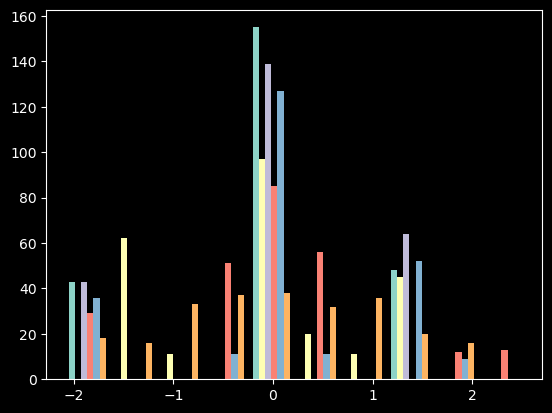

In [13]:
plt.hist(X_train)